In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 解決 matplotlib 中文顯示問題
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # macOS 使用 Arial Unicode MS
plt.rcParams['axes.unicode_minus'] = False  # 解決負號顯示問題

data = pd.read_csv('data_choice_complete.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45211 non-null  float64
 1   job        45211 non-null  float64
 2   marital    45211 non-null  float64
 3   education  45211 non-null  float64
 4   balance    45211 non-null  float64
 5   housing    45211 non-null  float64
 6   loan       45211 non-null  float64
 7   month      45211 non-null  float64
 8   duration   45211 non-null  float64
 9   campaign   45211 non-null  float64
 10  y          45211 non-null  int64  
dtypes: float64(10), int64(1)
memory usage: 3.8 MB


In [2]:
from sklearn.model_selection import train_test_split

X=data.drop('y', axis=1)
y=data['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((36168, 10), (9043, 10), (36168,), (9043,))

# Logistic Regression 與 Polynomial Regression 比較

本筆記本將比較兩種模型在相同資料集上的表現：
- **Logistic Regression**: 專為分類問題設計，輸出機率值 [0, 1]
- **Polynomial Regression**: 迴歸模型，輸出連續數值，需要閾值轉換為分類

評估指標：
1. 混淆矩陣相關指標（Accuracy, Precision, Recall, F1 Score）
2. ROC Curve 與 AUC

In [3]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("=" * 80)
print("訓練兩個模型...")
print("=" * 80)

# ==================== 1. Logistic Regression ====================
print("\n[1/2] 訓練 Logistic Regression...")
param_grid_log = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
grid_log = GridSearchCV(
    LogisticRegression(penalty='l2', max_iter=1000, random_state=100),
    param_grid_log,
    cv=5,
    scoring='accuracy'
)
grid_log.fit(X_train, y_train)
log_model = grid_log.best_estimator_

# 預測
y_pred_log = log_model.predict(X_test)
y_pred_log_proba = log_model.predict_proba(X_test)[:, 1]

print(f"✓ 最佳 C 值: {grid_log.best_params_['C']}")

# ==================== 2. Polynomial Regression ====================
print("\n[2/2] 訓練 Polynomial Regression...")
param_grid_poly = {'poly_features__degree': [2, 3, 4]}
poly_pipeline = Pipeline([
    ('poly_features', PolynomialFeatures()),
    ('linear_regression', LinearRegression())
])
grid_poly = GridSearchCV(
    poly_pipeline,
    param_grid_poly,
    cv=5,
    scoring='neg_mean_squared_error'
)
grid_poly.fit(X_train, y_train)
poly_model = grid_poly.best_estimator_

# 預測（連續數值）
y_pred_poly_raw = poly_model.predict(X_test)
# 轉為分類（閾值 0.5）
y_pred_poly = (y_pred_poly_raw >= 0.5).astype(int)

print(f"✓ 最佳 degree: {grid_poly.best_params_['poly_features__degree']}")
print(f"✓ 預測值範圍: [{y_pred_poly_raw.min():.4f}, {y_pred_poly_raw.max():.4f}]")

print("\n" + "=" * 80)
print("模型訓練完成！")
print("=" * 80)

訓練兩個模型...

[1/2] 訓練 Logistic Regression...
✓ 最佳 C 值: 100

[2/2] 訓練 Polynomial Regression...
✓ 最佳 C 值: 100

[2/2] 訓練 Polynomial Regression...
✓ 最佳 degree: 2
✓ 預測值範圍: [-0.4587, 0.7459]

模型訓練完成！
✓ 最佳 degree: 2
✓ 預測值範圍: [-0.4587, 0.7459]

模型訓練完成！


## 比較 1: 混淆矩陣與分類指標

比較兩個模型的：
- **Accuracy** (準確率): 整體預測正確的比例
- **Precision** (精確率): 預測為正類中，真正是正類的比例
- **Recall** (召回率): 實際為正類中，被正確找出的比例
- **F1 Score**: Precision 與 Recall 的調和平均

混淆矩陣與分類指標比較

分類指標比較表
指標                   |  Logistic Regression |  Polynomial Regression |         差異
--------------------------------------------------------------------------------
Accuracy (準確率)       |               0.8891 |                 0.8847 |    +0.0044
Precision (精確率)      |               0.6449 |                 0.0000 |    +0.6449
Recall (召回率)         |               0.0667 |                 0.0000 |    +0.0667
F1 Score             |               0.1209 |                 0.0000 |    +0.1209


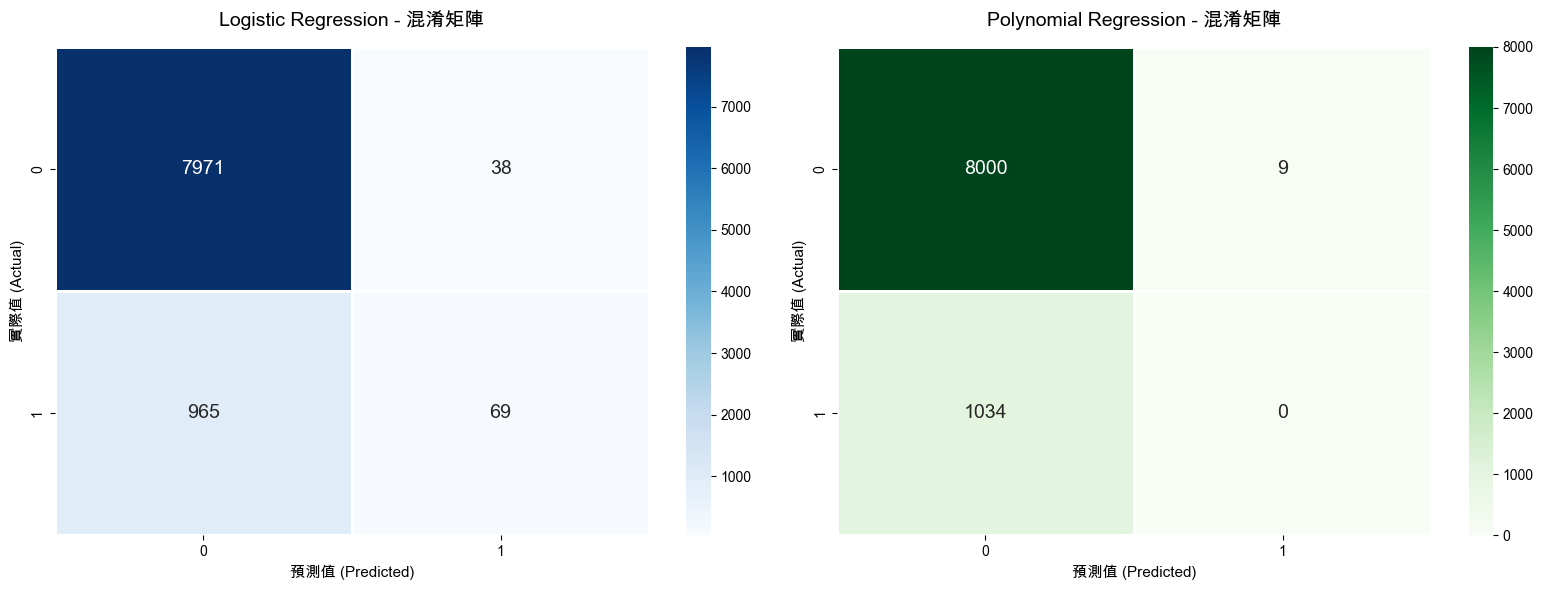


混淆矩陣詳細分析

【Logistic Regression】
  True Negative (TN):   7971 - 正確預測為「未訂閱」
  False Positive (FP):    38 - 錯誤預測為「訂閱」(Type I Error)
  False Negative (FN):   965 - 錯誤預測為「未訂閱」(Type II Error)
  True Positive (TP):     69 - 正確預測為「訂閱」

【Polynomial Regression】
  True Negative (TN):   8000 - 正確預測為「未訂閱」
  False Positive (FP):     9 - 錯誤預測為「訂閱」(Type I Error)
  False Negative (FN):  1034 - 錯誤預測為「未訂閱」(Type II Error)
  True Positive (TP):      0 - 正確預測為「訂閱」

結論
✓ Logistic Regression 在 F1 Score 上表現較佳 (0.1209 vs 0.0000)

• Logistic Regression 優勢: 專為分類設計，輸出機率易於解釋
• Polynomial Regression 劣勢: 需轉換為分類，可能產生不合理的預測值


In [4]:
# 計算評估指標
print("=" * 80)
print("混淆矩陣與分類指標比較")
print("=" * 80)

# Logistic Regression 指標
log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)
cm_log = confusion_matrix(y_test, y_pred_log)

# Polynomial Regression 指標
poly_accuracy = accuracy_score(y_test, y_pred_poly)
poly_precision = precision_score(y_test, y_pred_poly)
poly_recall = recall_score(y_test, y_pred_poly)
poly_f1 = f1_score(y_test, y_pred_poly)
cm_poly = confusion_matrix(y_test, y_pred_poly)

# 建立比較表格
print("\n" + "=" * 80)
print("分類指標比較表")
print("=" * 80)
print(f"{'指標':<20} | {'Logistic Regression':>20} | {'Polynomial Regression':>22} | {'差異':>10}")
print("-" * 80)
print(f"{'Accuracy (準確率)':<20} | {log_accuracy:>20.4f} | {poly_accuracy:>22.4f} | {(log_accuracy - poly_accuracy):>+10.4f}")
print(f"{'Precision (精確率)':<20} | {log_precision:>20.4f} | {poly_precision:>22.4f} | {(log_precision - poly_precision):>+10.4f}")
print(f"{'Recall (召回率)':<20} | {log_recall:>20.4f} | {poly_recall:>22.4f} | {(log_recall - poly_recall):>+10.4f}")
print(f"{'F1 Score':<20} | {log_f1:>20.4f} | {poly_f1:>22.4f} | {(log_f1 - poly_f1):>+10.4f}")

# 視覺化混淆矩陣
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Logistic Regression 混淆矩陣
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', cbar=True,
            annot_kws={'size': 14}, linewidths=2, linecolor='white', ax=axes[0])
axes[0].set_title('Logistic Regression - 混淆矩陣', fontsize=14, pad=15)
axes[0].set_ylabel('實際值 (Actual)', fontsize=11)
axes[0].set_xlabel('預測值 (Predicted)', fontsize=11)

# Polynomial Regression 混淆矩陣
sns.heatmap(cm_poly, annot=True, fmt='d', cmap='Greens', cbar=True,
            annot_kws={'size': 14}, linewidths=2, linecolor='white', ax=axes[1])
axes[1].set_title('Polynomial Regression - 混淆矩陣', fontsize=14, pad=15)
axes[1].set_ylabel('實際值 (Actual)', fontsize=11)
axes[1].set_xlabel('預測值 (Predicted)', fontsize=11)

plt.tight_layout()
plt.show()

# 詳細分析
print("\n" + "=" * 80)
print("混淆矩陣詳細分析")
print("=" * 80)

for model_name, cm in [("Logistic Regression", cm_log), ("Polynomial Regression", cm_poly)]:
    TN, FP, FN, TP = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
    print(f"\n【{model_name}】")
    print(f"  True Negative (TN):  {TN:5d} - 正確預測為「未訂閱」")
    print(f"  False Positive (FP): {FP:5d} - 錯誤預測為「訂閱」(Type I Error)")
    print(f"  False Negative (FN): {FN:5d} - 錯誤預測為「未訂閱」(Type II Error)")
    print(f"  True Positive (TP):  {TP:5d} - 正確預測為「訂閱」")

print("\n" + "=" * 80)
print("結論")
print("=" * 80)

# 判斷哪個模型較好
if log_f1 > poly_f1:
    print(f"✓ Logistic Regression 在 F1 Score 上表現較佳 ({log_f1:.4f} vs {poly_f1:.4f})")
elif poly_f1 > log_f1:
    print(f"✓ Polynomial Regression 在 F1 Score 上表現較佳 ({poly_f1:.4f} vs {log_f1:.4f})")
else:
    print(f"○ 兩個模型的 F1 Score 相同 ({log_f1:.4f})")

print(f"\n• Logistic Regression 優勢: 專為分類設計，輸出機率易於解釋")
print(f"• Polynomial Regression 劣勢: 需轉換為分類，可能產生不合理的預測值")

## 比較 2: ROC Curve 與 AUC

ROC Curve 評估模型在「所有可能閾值」下的表現：
- **X 軸 (FPR)**: False Positive Rate - 誤判率
- **Y 軸 (TPR)**: True Positive Rate - 召回率
- **AUC**: ROC 曲線下方的面積，越大越好（最大值 1.0）

**優勢**: 不受閾值影響，能全面評估模型的分類能力

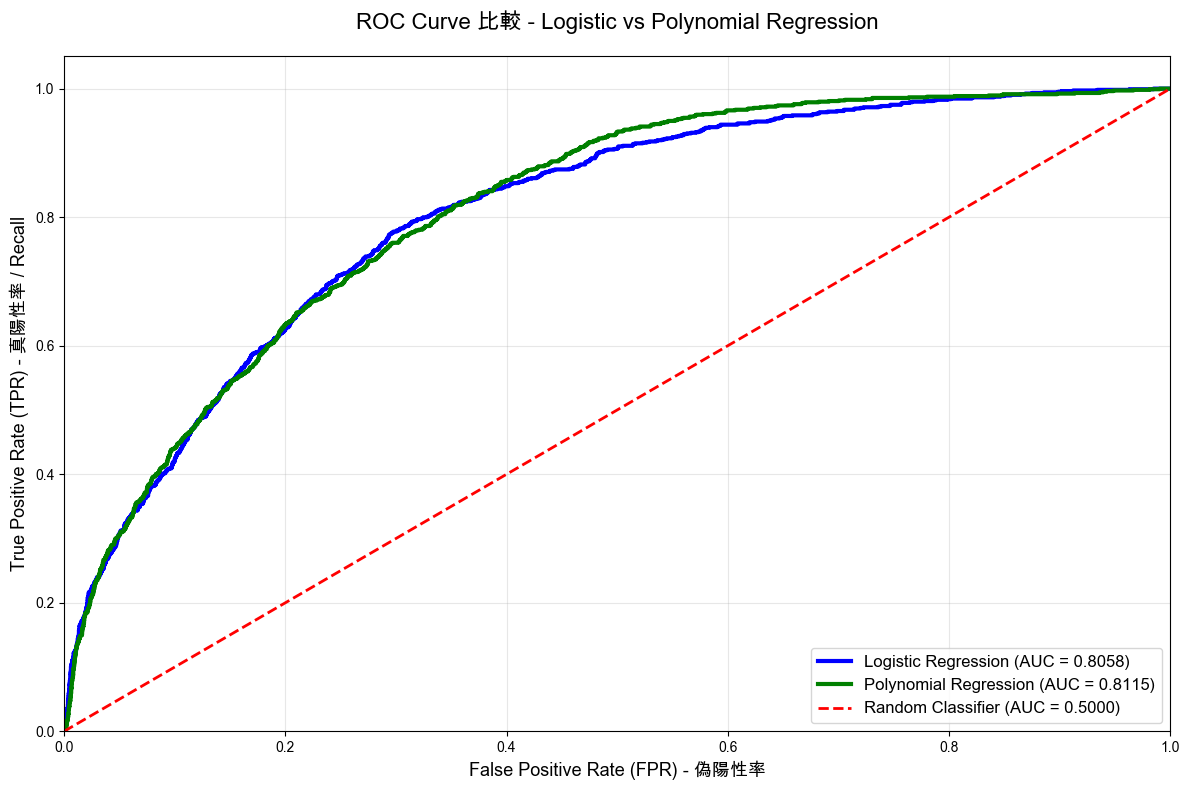

ROC Curve & AUC 比較結果

Logistic Regression  AUC: 0.8058
Polynomial Regression AUC: 0.8115
差異: -0.0057

AUC 評估標準:
Logistic Regression      : AUC = 0.8058 → 良好 (Good)
Polynomial Regression    : AUC = 0.8115 → 良好 (Good)

ROC Curve 解讀:
✓ Polynomial Regression 的 AUC 較高，表示整體分類能力較好
  → 多項式特徵提供了額外的預測能力

• 曲線越靠近左上角越好（高 TPR、低 FPR）
• AUC 代表隨機挑選一個正樣本和負樣本，模型正確排序的機率


In [5]:
# 計算 ROC Curve
fpr_log, tpr_log, thresholds_log = roc_curve(y_test, y_pred_log_proba)
fpr_poly, tpr_poly, thresholds_poly = roc_curve(y_test, y_pred_poly_raw)

# 計算 AUC
auc_log = auc(fpr_log, tpr_log)
auc_poly = auc(fpr_poly, tpr_poly)

# 繪製 ROC Curve 比較
plt.figure(figsize=(12, 8))

# Logistic Regression
plt.plot(fpr_log, tpr_log, color='blue', lw=3, 
         label=f'Logistic Regression (AUC = {auc_log:.4f})')

# Polynomial Regression
plt.plot(fpr_poly, tpr_poly, color='green', lw=3, 
         label=f'Polynomial Regression (AUC = {auc_poly:.4f})')

# 隨機分類器基準線
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', 
         label='Random Classifier (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR) - 偽陽性率', fontsize=13)
plt.ylabel('True Positive Rate (TPR) - 真陽性率 / Recall', fontsize=13)
plt.title('ROC Curve 比較 - Logistic vs Polynomial Regression', fontsize=16, pad=20)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# AUC 比較
print("=" * 80)
print("ROC Curve & AUC 比較結果")
print("=" * 80)
print(f"\nLogistic Regression  AUC: {auc_log:.4f}")
print(f"Polynomial Regression AUC: {auc_poly:.4f}")
print(f"差異: {(auc_log - auc_poly):+.4f}")

print("\n" + "=" * 80)
print("AUC 評估標準:")
print("=" * 80)

def evaluate_auc(auc_score, model_name):
    if auc_score >= 0.9:
        level = "優秀 (Excellent)"
    elif auc_score >= 0.8:
        level = "良好 (Good)"
    elif auc_score >= 0.7:
        level = "尚可 (Fair)"
    elif auc_score >= 0.6:
        level = "不佳 (Poor)"
    else:
        level = "失敗 (Fail)"
    print(f"{model_name:<25}: AUC = {auc_score:.4f} → {level}")

evaluate_auc(auc_log, "Logistic Regression")
evaluate_auc(auc_poly, "Polynomial Regression")

print("\n" + "=" * 80)
print("ROC Curve 解讀:")
print("=" * 80)
if auc_log > auc_poly:
    print(f"✓ Logistic Regression 的 AUC 較高，表示整體分類能力較好")
    print(f"  → 在各種閾值下，Logistic Regression 都有較佳的 TPR/FPR 平衡")
elif auc_poly > auc_log:
    print(f"✓ Polynomial Regression 的 AUC 較高，表示整體分類能力較好")
    print(f"  → 多項式特徵提供了額外的預測能力")
else:
    print(f"○ 兩個模型的 AUC 相同，分類能力相當")

print(f"\n• 曲線越靠近左上角越好（高 TPR、低 FPR）")
print(f"• AUC 代表隨機挑選一個正樣本和負樣本，模型正確排序的機率")

## 總結比較

綜合兩種評估方法的結果：

In [6]:
print("=" * 80)
print("最終總結：Logistic Regression vs Polynomial Regression")
print("=" * 80)

# 建立總結表格
print("\n" + "=" * 80)
print("完整評估指標比較")
print("=" * 80)
print(f"{'評估指標':<25} | {'Logistic':>15} | {'Polynomial':>15} | {'較佳模型':>15}")
print("-" * 80)
print(f"{'Accuracy':<25} | {log_accuracy:>15.4f} | {poly_accuracy:>15.4f} | {'Logistic' if log_accuracy > poly_accuracy else 'Polynomial' if poly_accuracy > log_accuracy else '相同':>15}")
print(f"{'Precision':<25} | {log_precision:>15.4f} | {poly_precision:>15.4f} | {'Logistic' if log_precision > poly_precision else 'Polynomial' if poly_precision > log_precision else '相同':>15}")
print(f"{'Recall':<25} | {log_recall:>15.4f} | {poly_recall:>15.4f} | {'Logistic' if log_recall > poly_recall else 'Polynomial' if poly_recall > log_recall else '相同':>15}")
print(f"{'F1 Score':<25} | {log_f1:>15.4f} | {poly_f1:>15.4f} | {'Logistic' if log_f1 > poly_f1 else 'Polynomial' if poly_f1 > log_f1 else '相同':>15}")
print(f"{'AUC':<25} | {auc_log:>15.4f} | {auc_poly:>15.4f} | {'Logistic' if auc_log > auc_poly else 'Polynomial' if auc_poly > auc_log else '相同':>15}")

print("\n" + "=" * 80)
print("模型特性比較")
print("=" * 80)

print("\n【Logistic Regression】")
print("✓ 優點:")
print("  • 專為二元分類設計，輸出 [0, 1] 的機率值")
print("  • 模型簡單，易於解釋和部署")
print("  • 訓練速度快，參數少（只需調整 C）")
print("  • 預測結果符合機率定義，適合需要機率輸出的場景")
print("✗ 缺點:")
print("  • 假設特徵與目標呈線性關係")
print("  • 無法捕捉複雜的非線性模式")

print("\n【Polynomial Regression】")
print("✓ 優點:")
print("  • 透過多項式特徵捕捉非線性關係")
print("  • 可能發現特徵間的交互作用")
print("✗ 缺點:")
print("  • 本質是迴歸模型，輸出連續值，可能超出 [0, 1] 範圍")
print(f"    → 本次實驗預測範圍: [{y_pred_poly_raw.min():.4f}, {y_pred_poly_raw.max():.4f}]")
print("  • 需要閾值轉換才能用於分類")
print("  • 特徵數量隨 degree 急劇增加，容易過擬合")
print("  • 訓練時間較長，模型複雜度高")

print("\n" + "=" * 80)
print("建議")
print("=" * 80)

# 計算整體得分（簡單平均）
log_avg_score = (log_accuracy + log_precision + log_recall + log_f1 + auc_log) / 5
poly_avg_score = (poly_accuracy + poly_precision + poly_recall + poly_f1 + auc_poly) / 5

print(f"\n整體平均分數:")
print(f"  Logistic Regression:  {log_avg_score:.4f}")
print(f"  Polynomial Regression: {poly_avg_score:.4f}")

if log_avg_score > poly_avg_score:
    print(f"\n✓ 推薦使用 Logistic Regression")
    print(f"  理由: 整體表現較佳，且模型更簡單、易於解釋")
elif poly_avg_score > log_avg_score:
    print(f"\n✓ 推薦使用 Polynomial Regression")
    print(f"  理由: 整體表現較佳，多項式特徵提供了額外價值")
else:
    print(f"\n○ 兩個模型表現相當")
    print(f"  建議: 優先選擇 Logistic Regression（更簡單、更快）")

print(f"\n對於二元分類問題，Logistic Regression 通常是更合適的選擇。")
print(f"Polynomial Regression 適合用於「真正的迴歸問題」(預測連續數值)。")

最終總結：Logistic Regression vs Polynomial Regression

完整評估指標比較
評估指標                      |        Logistic |      Polynomial |            較佳模型
--------------------------------------------------------------------------------
Accuracy                  |          0.8891 |          0.8847 |        Logistic
Precision                 |          0.6449 |          0.0000 |        Logistic
Recall                    |          0.0667 |          0.0000 |        Logistic
F1 Score                  |          0.1209 |          0.0000 |        Logistic
AUC                       |          0.8058 |          0.8115 |      Polynomial

模型特性比較

【Logistic Regression】
✓ 優點:
  • 專為二元分類設計，輸出 [0, 1] 的機率值
  • 模型簡單，易於解釋和部署
  • 訓練速度快，參數少（只需調整 C）
  • 預測結果符合機率定義，適合需要機率輸出的場景
✗ 缺點:
  • 假設特徵與目標呈線性關係
  • 無法捕捉複雜的非線性模式

【Polynomial Regression】
✓ 優點:
  • 透過多項式特徵捕捉非線性關係
  • 可能發現特徵間的交互作用
✗ 缺點:
  • 本質是迴歸模型，輸出連續值，可能超出 [0, 1] 範圍
    → 本次實驗預測範圍: [-0.4587, 0.7459]
  • 需要閾值轉換才能用於分類
  • 特徵數量隨 degree 急劇增加，容易過擬合
  • 訓練時間較長，模型複雜度高

建議

